In [1]:
# CELL 1: Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

C:\Users\baska\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✓ All imports successful!
NumPy version: 2.3.3
Pandas version: 3.0.3


In [2]:
# CELL 2: Load Raw Data

# Load the 3 CSV files
print("Loading data...")

activity_df = pd.read_csv('../../data/raw/dailyActivity_merged.csv')
sleep_df = pd.read_csv('../../data/raw/sleepDay_merged.csv')
weight_df = pd.read_csv('../../data/raw/weightLogInfo_merged.csv')

print("✓ Data loaded successfully!\n")

print(f"Activity data shape: {activity_df.shape}")
print(f"Sleep data shape: {sleep_df.shape}")
print(f"Weight data shape: {weight_df.shape}")

Loading data...
✓ Data loaded successfully!

Activity data shape: (940, 15)
Sleep data shape: (413, 5)
Weight data shape: (67, 8)


In [3]:
# CELL 3: Explore Activity Data

print("="*60)
print("ACTIVITY DATA EXPLORATION")
print("="*60)

print("\nFirst 5 rows:")
print(activity_df.head())

print("\nColumn names and types:")
print(activity_df.dtypes)

print("\nDataset shape:", activity_df.shape)
print(f"Rows: {activity_df.shape[0]}, Columns: {activity_df.shape[1]}")

print("\nMissing values:")
print(activity_df.isnull().sum())

print("\nDuplicate rows:", activity_df.duplicated().sum())

print("\nBasic statistics:")
print(activity_df.describe())

print("\nTarget variable (Calories) statistics:")
print(activity_df['Calories'].describe())

ACTIVITY DATA EXPLORATION

First 5 rows:
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.71                      0.41   

   LightActiveDistance  SedentaryActiveDistance  Ve

In [4]:
# CELL 4: Explore Sleep & Weight Data

print("\n" + "="*60)
print("SLEEP DATA EXPLORATION")
print("="*60)

print("\nFirst 5 rows:")
print(sleep_df.head())

print("\nColumn names and types:")
print(sleep_df.dtypes)

print("\nSleep data shape:", sleep_df.shape)
print("Missing values:")
print(sleep_df.isnull().sum())

print("\nBasic statistics:")
print(sleep_df.describe())

print("\n" + "="*60)
print("WEIGHT DATA EXPLORATION")
print("="*60)

print("\nFirst 5 rows:")
print(weight_df.head())

print("\nColumn names and types:")
print(weight_df.dtypes)

print("\nWeight data shape:", weight_df.shape)
print("Missing values:")
print(weight_df.isnull().sum())

print("\nBasic statistics:")
print(weight_df.describe())


SLEEP DATA EXPLORATION

First 5 rows:
           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed  
0             346  
1             407  
2             442  
3             367  
4             712  

Column names and types:
Id                    int64
SleepDay                str
TotalSleepRecords     int64
TotalMinutesAsleep    int64
TotalTimeInBed        int64
dtype: object

Sleep data shape: (413, 5)
Missing values:
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

Basic sta

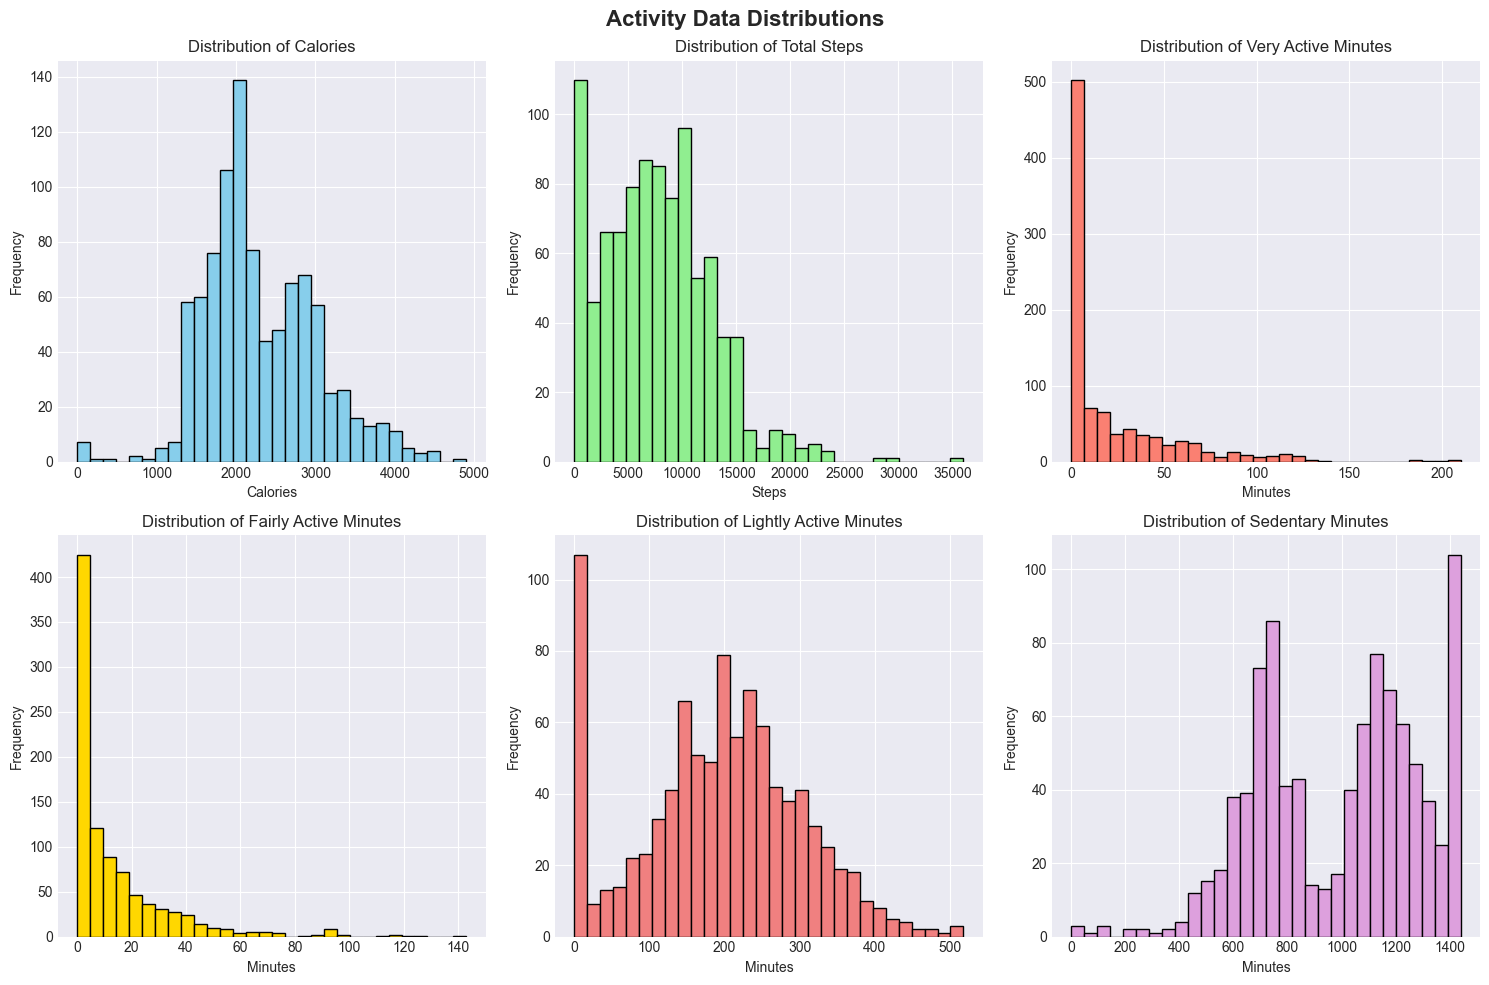

✓ Distribution plots saved!


In [5]:
# CELL 5: Data Distribution - Visualizations

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Activity Data Distributions', fontsize=16, fontweight='bold')

# Calories
axes[0, 0].hist(activity_df['Calories'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribution of Calories')
axes[0, 0].set_xlabel('Calories')
axes[0, 0].set_ylabel('Frequency')

# Total Steps
axes[0, 1].hist(activity_df['TotalSteps'], bins=30, edgecolor='black', color='lightgreen')
axes[0, 1].set_title('Distribution of Total Steps')
axes[0, 1].set_xlabel('Steps')
axes[0, 1].set_ylabel('Frequency')

# Very Active Minutes
axes[0, 2].hist(activity_df['VeryActiveMinutes'], bins=30, edgecolor='black', color='salmon')
axes[0, 2].set_title('Distribution of Very Active Minutes')
axes[0, 2].set_xlabel('Minutes')
axes[0, 2].set_ylabel('Frequency')

# Fairly Active Minutes
axes[1, 0].hist(activity_df['FairlyActiveMinutes'], bins=30, edgecolor='black', color='gold')
axes[1, 0].set_title('Distribution of Fairly Active Minutes')
axes[1, 0].set_xlabel('Minutes')
axes[1, 0].set_ylabel('Frequency')

# Lightly Active Minutes
axes[1, 1].hist(activity_df['LightlyActiveMinutes'], bins=30, edgecolor='black', color='lightcoral')
axes[1, 1].set_title('Distribution of Lightly Active Minutes')
axes[1, 1].set_xlabel('Minutes')
axes[1, 1].set_ylabel('Frequency')

# Sedentary Minutes
axes[1, 2].hist(activity_df['SedentaryMinutes'], bins=30, edgecolor='black', color='plum')
axes[1, 2].set_title('Distribution of Sedentary Minutes')
axes[1, 2].set_xlabel('Minutes')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("✓ Distribution plots saved!")

In [6]:
# CELL 6: Prepare Data for Merging

# Convert date columns to datetime
activity_df['ActivityDate'] = pd.to_datetime(activity_df['ActivityDate'])
sleep_df['SleepDay'] = pd.to_datetime(sleep_df['SleepDay'])
weight_df['Date'] = pd.to_datetime(weight_df['Date'])

# Create date column (without time) for merging
activity_df['Date'] = activity_df['ActivityDate'].dt.date
sleep_df['Date'] = sleep_df['SleepDay'].dt.date
weight_df['Date'] = weight_df['Date'].dt.date

print("✓ Date columns prepared")
print(f"\nActivity date range: {activity_df['Date'].min()} to {activity_df['Date'].max()}")
print(f"Sleep date range: {sleep_df['Date'].min()} to {sleep_df['Date'].max()}")
print(f"Weight date range: {weight_df['Date'].min()} to {weight_df['Date'].max()}")

✓ Date columns prepared

Activity date range: 2016-04-12 to 2016-05-12
Sleep date range: 2016-04-12 to 2016-05-12
Weight date range: 2016-04-12 to 2016-05-12


In [7]:
# CELL 7: Merge Datasets

print("Merging datasets...")

# Select only necessary columns from sleep
sleep_merge = sleep_df[['Id', 'Date', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']]

# Select only necessary columns from weight
weight_merge = weight_df[['Id', 'Date', 'WeightKg', 'BMI', 'Fat']]

# Merge activity with sleep (left join - keep all activity rows)
merged_df = activity_df.merge(sleep_merge, on=['Id', 'Date'], how='left')

# Merge with weight (left join - keep all activity rows)
merged_df = merged_df.merge(weight_merge, on=['Id', 'Date'], how='left')

print(f"✓ Datasets merged!")
print(f"\nMerged dataset shape: {merged_df.shape}")
print(f"Rows: {merged_df.shape[0]}, Columns: {merged_df.shape[1]}")

print("\nFirst 5 rows of merged data:")
print(merged_df.head())

print("\nMissing values after merge:")
print(merged_df.isnull().sum())

Merging datasets...
✓ Datasets merged!

Merged dataset shape: (943, 22)
Rows: 943, Columns: 22

First 5 rows of merged data:
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366   2016-04-12       13162           8.50             8.50   
1  1503960366   2016-04-13       10735           6.97             6.97   
2  1503960366   2016-04-14       10460           6.74             6.74   
3  1503960366   2016-04-15        9762           6.28             6.28   
4  1503960366   2016-04-16       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.

In [8]:
# CELL 8 ALTERNATIVE: More Robust Missing Value Handling

print("="*60)
print("PREPROCESSING - ROBUST VERSION")
print("="*60)

print("\nMissing values before preprocessing:")
missing_before = merged_df.isnull().sum()
print(missing_before[missing_before > 0])

# Select only numerical columns
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns

print("\n" + "-"*60)
print("Strategy: Median Imputation")
print("-"*60)

# Create a copy to avoid SettingWithCopyWarning
imputed_data = merged_df[numerical_cols].copy()

# Fill with median for each column
for col in numerical_cols:
    if imputed_data[col].isnull().sum() > 0:
        median_val = imputed_data[col].median()
        imputed_data[col] = imputed_data[col].fillna(median_val)
        print(f"✓ {col}: Filled {missing_before[col]} NaN values (median = {median_val:.2f})")

# Replace original columns with imputed data
merged_df[numerical_cols] = imputed_data

# Verify
print("\n" + "-"*60)
print("Verification:")
print("-"*60)

missing_after = merged_df.isnull().sum()
print(f"\nMissing values after preprocessing:")
total_missing = missing_after.sum()

if total_missing == 0:
    print("✓ All missing values handled successfully!")
    print("✓ Dataset ready for feature engineering!")
else:
    print(f"⚠️  Warning: {total_missing} missing values remain")
    print(missing_after[missing_after > 0])

PREPROCESSING - ROBUST VERSION

Missing values before preprocessing:
TotalSleepRecords     530
TotalMinutesAsleep    530
TotalTimeInBed        530
WeightKg              876
BMI                   876
Fat                   941
dtype: int64

------------------------------------------------------------
Strategy: Median Imputation
------------------------------------------------------------
✓ TotalSleepRecords: Filled 530 NaN values (median = 1.00)
✓ TotalMinutesAsleep: Filled 530 NaN values (median = 433.00)
✓ TotalTimeInBed: Filled 530 NaN values (median = 463.00)
✓ WeightKg: Filled 876 NaN values (median = 62.50)
✓ BMI: Filled 876 NaN values (median = 24.39)
✓ Fat: Filled 941 NaN values (median = 23.50)

------------------------------------------------------------
Verification:
------------------------------------------------------------

Missing values after preprocessing:
✓ All missing values handled successfully!
✓ Dataset ready for feature engineering!
